Principal component analisys

In [38]:
import numpy as np

In [39]:
import urllib.request
urllib.request.urlretrieve("https://raw.githubusercontent.com/nshaud/ml_for_astro/main/stars.csv", "stars.csv")

('stars.csv', <http.client.HTTPMessage at 0x1e2d0dc7be0>)

In [40]:
import pandas as pd
df_stars = pd.read_csv("stars.csv")

In [41]:
df_stars

,Temperature (K),Luminosity(L/Lo),Radius(R/Ro),Absolute magnitude(Mv),Star type,Star color,Spectral Class
0,3068,0.002400,0.1700,16.12,Brown Dwarf,Red,M
1,3042,0.000500,0.1542,16.60,Brown Dwarf,Red,M
2,2600,0.000300,0.1020,18.70,Brown Dwarf,Red,M
3,2800,0.000200,0.1600,16.65,Brown Dwarf,Red,M
4,1939,0.000138,0.1030,20.06,Brown Dwarf,Red,M
...,...,...,...,...,...,...,...
235,38940,374830.000000,1356.0000,-9.93,Hypergiant,Blue,O
236,30839,834042.000000,1194.0000,-10.63,Hypergiant,Blue,O
237,8829,537493.000000,1423.0000,-10.73,Hypergiant,White,A
238,9235,404940.000000,1112.0000,-11.23,Hypergiant,White,A


In [42]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
# Assign unique integers from 0 to 6 to each star type
df_stars['Star type'] = le.fit_transform(df_stars['Star type'])
labels = le.inverse_transform(df_stars['Star type'])
class_names = le.classes_
print(class_names)

['Brown Dwarf' 'Hypergiant' 'Main Sequence' 'Red Dwarf' 'Supergiant'
 'White Dwarf']


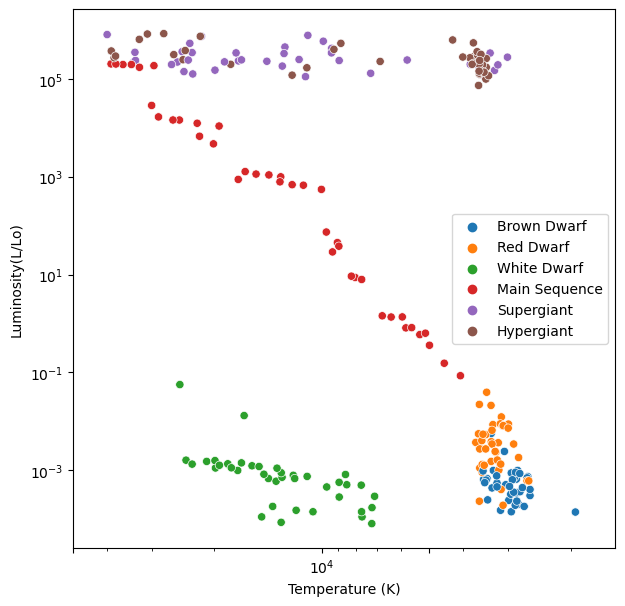

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

fig = plt.figure(figsize=(7, 7))
sns.scatterplot(data=df_stars, x='Temperature (K)', y='Luminosity(L/Lo)', hue=labels)

plt.xscale('log')
plt.yscale('log')
plt.xticks([5000, 10000, 50000])
plt.xlim(5e4, 1.5e3)
plt.show()

In [44]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

df_stars.drop(["Star type", "Star color", "Spectral Class"], axis=1, inplace=True)

X = np.array(df_stars)

pca.fit(X) 

eigenvalues = pca.transform(X)
mean = pca.mean_
eigenvectors = pca.components_

print(eigenvalues.shape)
print(eigenvectors.shape)

(240, 2)
(2, 4)


<Axes: >

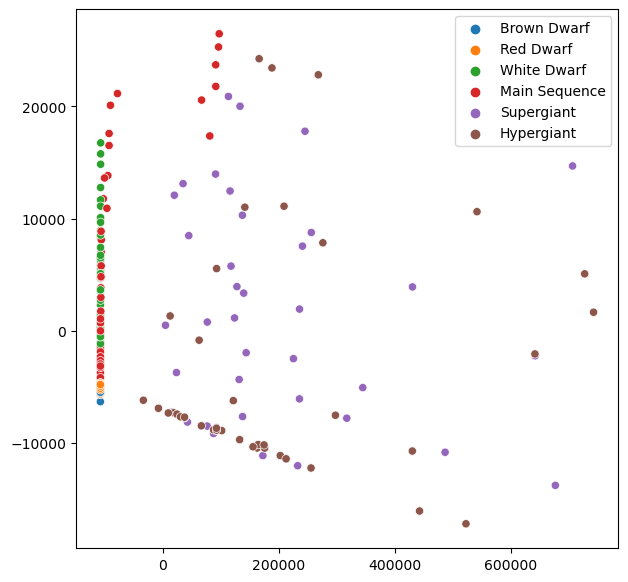

In [45]:
fig = plt.figure(figsize=(7, 7))
sns.scatterplot(x=eigenvalues[:,0], y=eigenvalues[:,1], hue=labels)

<Axes: >

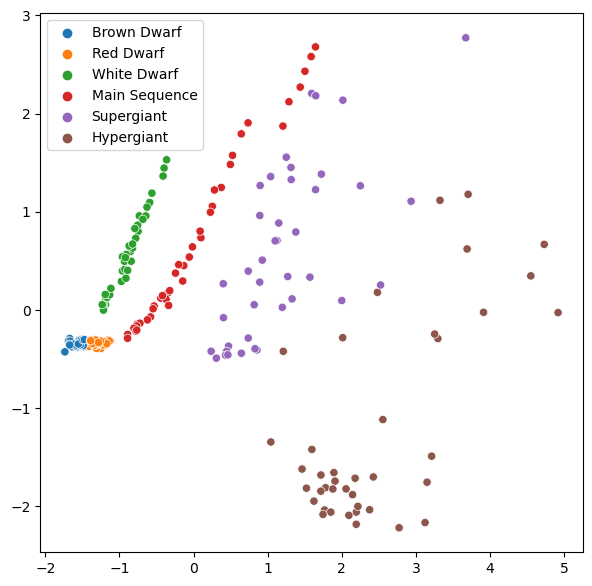

In [46]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(df_stars)

pca = PCA(n_components=2)
projected_stars = pca.fit_transform(X)

fig = plt.figure(figsize=(7, 7))
sns.scatterplot(x=projected_stars[:,0], y=projected_stars[:,1], hue=labels)

In [47]:
evals = pca.explained_variance_ratio_
print(evals)

[0.60357391 0.23500784]
